# Notebook 1 — Dataset construction

**Project**: Probabilistic soil-contamination mapping under detection-limit censoring at the
Santa Bárbara mercury mine, Huancavelica, Peru.

**What this notebook does**: builds the analysis dataset from the raw OEFA environmental
assessment, attaches terrain and distance covariates, runs coordinate quality control, and
exports the table plus its data dictionary.

**Source**: OEFA report **00341-2018-OEFA/DEAM-STEC**, *Evaluación ambiental en el área de
influencia de la unidad minera Santa Bárbara*. Soil sampling 18 July – 9 September 2018,
UTM zone 18S (WGS84), elevation 4 095–4 546 m a.s.l.

**Why this site**. The Santa Bárbara mercury mine operated from 1573 to 1970 and released an
estimated 17 000 metric tons of mercury vapour between 1564 and 1810 (Robins, 2011). A December
2023 ruling of the Civil Chamber of the Superior Court of Huancavelica ordered the State to
identify the contaminated sites; environmental emergency was declared in April 2024; as of
February 2025 no site-identification report had been produced. This notebook builds the data
layer for exactly that missing instrument.

## 1. Setup, seed and versions

In [1]:
from __future__ import annotations

import json
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 20260906
rng = np.random.default_rng(SEED)

PROJ = Path(r"c:\Users\diego\OneDrive\Documentos\ANALISIS BAYESIANO\proyecto_metales_bayesiano")
DIR_OEFA = PROJ / "data" / "fase1" / "oefa"
DIR_COV = PROJ / "data" / "fase1" / "covariables"
DIR_FINAL = PROJ / "data" / "final"
DIR_FIG = PROJ / "figuras"
DIR_OUT = PROJ / "outputs"
for d in (DIR_FINAL, DIR_FIG, DIR_OUT):
    d.mkdir(parents=True, exist_ok=True)

CRS_UTM = "EPSG:32718"   # WGS84 / UTM zone 18S -> metric distances
CRS_GEO = "EPSG:4326"    # WGS84 geographic

EVALUATION = "Santa Bárbara"
REPORT_ID = "INFORME N° 00341-2018-OEFA/DEAM-STEC"

print("Python     :", sys.version.split()[0])
for mod in ["numpy", "pandas", "matplotlib", "geopandas", "pyproj", "rasterio", "shapely",
            "openpyxl", "esda", "libpysal"]:
    try:
        m = __import__(mod)
        print(f"{mod:<11}: {getattr(m, '__version__', 'n/a')}")
    except Exception as e:
        print(f"{mod:<11}: MISSING ({e})")
print("Seed       :", SEED)

Python     : 3.14.5
numpy      : 2.4.6
pandas     : 2.3.3
matplotlib : 3.11.0
geopandas  : 1.1.4
pyproj     : 3.7.2
rasterio   : 1.5.1
shapely    : 2.1.2


openpyxl   : 3.1.5


esda       : 2.10.0
libpysal   : 4.15.0
Seed       : 20260906


### Figure style — journal standard (Q1/Q2)

Elsevier/Springer column widths: 90 mm (single), 140 mm (1.5), 190 mm (double). 7 pt sans-serif,
embedded fonts (`pdf.fonttype=42`), colour-blind-safe palettes.

`savefig.bbox` is set to `"standard"` on purpose. With `constrained_layout=True` Matplotlib
already fits everything inside `figsize`, whereas `"tight"` crops to content and shifts the final
width (190 mm comes out as 193 mm). Note that passing `savefig(bbox_inches=None)` does **not**
disable cropping — `None` falls back to the rcParam.

In [2]:
MM = 1 / 25.4
W1, W15, W2 = 90 * MM, 140 * MM, 190 * MM

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 0.9,
    "savefig.dpi": 600, "savefig.bbox": "standard",
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "figure.dpi": 140,
})

# Okabe-Ito, colour-blind safe
OI = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#56B4E9", "#CC79A7", "#F0E442", "#000000"]


def save_fig(fig, stem, dpi_tiff=600):
    """Export to vector PDF and high-resolution TIFF at the exact declared width."""
    fig.savefig(DIR_FIG / f"{stem}.pdf")
    fig.savefig(DIR_FIG / f"{stem}.tif", dpi=dpi_tiff, pil_kwargs={"compression": "tiff_lzw"})
    print(f"saved: {stem} (.pdf, .tif) | width {fig.get_size_inches()[0]*25.4:.0f} mm | {dpi_tiff} dpi")


def scale_bar(ax, length_km=0.5, label=None, pos=(0.06, 0.06)):
    """Scale bar for axes whose units are kilometres."""
    x0, y0 = ax.get_xlim()[0], ax.get_ylim()[0]
    dx, dy = np.diff(ax.get_xlim())[0], np.diff(ax.get_ylim())[0]
    xa, ya = x0 + pos[0] * dx, y0 + pos[1] * dy
    ax.plot([xa, xa + length_km], [ya, ya], color="k", lw=1.4, solid_capstyle="butt", zorder=10)
    ax.text(xa + length_km / 2, ya + 0.015 * dy, label or f"{length_km:g} km",
            ha="center", va="bottom", fontsize=6, zorder=10)


def north_arrow(ax, pos=(0.93, 0.80), length=0.10):
    ax.annotate("N", xy=(pos[0], pos[1] + length), xytext=pos, xycoords="axes fraction",
                textcoords="axes fraction", ha="center", va="bottom", fontsize=6.5,
                fontweight="bold",
                arrowprops=dict(arrowstyle="-|>", color="k", lw=0.8, mutation_scale=7))


def to_latex(df, name, caption, label, floatfmt=3):
    """Write a table as LaTeX, ready to paste into the manuscript."""
    d2 = df.copy()
    for c in d2.columns:
        if pd.api.types.is_float_dtype(d2[c]):
            d2[c] = d2[c].map(lambda v: "" if pd.isna(v) else f"{v:.{floatfmt}f}")
    body = d2.to_latex(index=False, escape=True,
                       column_format="l" * 2 + "r" * max(0, d2.shape[1] - 2))
    tex = ("\\begin{table}[htbp]\n\\centering\n\\caption{" + caption + "}\n"
           "\\label{" + label + "}\n\\footnotesize\n" + body + "\\end{table}\n")
    (DIR_FIG / f"{name}.tex").write_text(tex, encoding="utf-8")


def save_table(df, name, caption=None, label=None, index=False, floatfmt=3):
    df.to_csv(DIR_FIG / f"{name}.csv", index=index, encoding="utf-8")
    if caption:
        to_latex(df.reset_index() if index else df, name, caption, label or name, floatfmt)
    print(f"table: {name}.csv" + (" + .tex" if caption else ""))

## 2. Load and filter

Filters replicate the ones validated in the previous phase of this project:

1. `Nombre de la Evaluación` contains "Santa Bárbara" — single report, 00341-2018-OEFA/DEAM-STEC.
2. `Tipo de análisis = "Metales totales"`. Sequential Tessier extraction, SPLP leachate,
   granulometry and ABA are different measurands and are excluded. The Peruvian soil standard
   (D.S. 011-2017-MINAM) is defined on total metals with EPA 3050/3051 digestion, which fixes
   this as the correct fraction.
3. `Procedencia de la Muestra = "Suelo"`. Excludes `Suelo - Materiales de actividad minera`
   (waste-rock and outcrop samples): those are mine material, not soil, and belong to a different
   population. They are kept aside — they give us the exact coordinates of the mine workings.

In [3]:
COL_MAP = {
    "número de informe": "report", "nombre de la evaluación": "evaluation", "etapa": "stage",
    "componente ambiental": "component", "procedencia de la muestra": "provenance",
    "procedencia especifica de la muestra": "stratum_raw", "nombre del punto": "point_name",
    "este": "easting", "norte": "northing", "altitud": "elev_oefa", "zona": "utm_zone",
    "datum": "datum", "descripción de ubicación": "description", "tipo de muestra": "sample_type_raw",
    "tipo de análisis": "analysis_type", "etapa de extracción secuencial": "extraction",
    "caracterización de la muestra": "characterisation", "fecha": "date", "hora": "time",
    "valor": "value_txt", "parámetro": "analyte_es", "unidad de medida": "unit",
}

raw = pd.read_excel(DIR_OEFA / "suelo__EAC-COMPO-AMBIE-SUELO.xlsx", dtype=str)
raw.columns = [COL_MAP.get(str(c).strip().lower(), str(c).strip().lower()) for c in raw.columns]
print("rows in source workbook:", len(raw))

steps = [("0. Source workbook", len(raw))]
sb = raw[raw["evaluation"].astype(str).str.contains(EVALUATION, case=False, na=False)].copy()
steps.append(("1. Evaluation = Santa Bárbara", len(sb)))
assert sb["report"].nunique() == 1 and sb["report"].iloc[0] == REPORT_ID

mine_material = sb[(sb["analysis_type"] == "Metales totales")
                   & (sb["provenance"] == "Suelo - Materiales de actividad minera")].copy()

sb = sb[sb["analysis_type"] == "Metales totales"]
steps.append(("2. Analysis type = total metals", len(sb)))
sb = sb[sb["provenance"] == "Suelo"]
steps.append(("3. Provenance = soil (excl. mine material)", len(sb)))

print(pd.DataFrame(steps, columns=["Filtering step", "Rows"]).to_string(index=False))
print("\nunique point names:", sb["point_name"].nunique())
print("date range:", pd.to_datetime(sb["date"]).min().date(), "to",
      pd.to_datetime(sb["date"]).max().date())
print("units:", sorted(sb["unit"].unique()), "| UTM zone:", sb["utm_zone"].unique(),
      "| datum:", sb["datum"].unique())
print("analytes:", sb["analyte_es"].nunique())

rows in source workbook: 99077


                            Filtering step  Rows
                        0. Source workbook 99077
             1. Evaluation = Santa Bárbara  5886
           2. Analysis type = total metals  4352
3. Provenance = soil (excl. mine material)  3680

unique point names: 115
date range: 2018-07-18 to 2018-09-09
units: ['mg/Kg'] | UTM zone: ['18'] | datum: ['WGS84']
analytes: 32


## 3. Sampling design: two strata, two supports

The survey is **stratified by design**, and this is central to the analysis rather than a detail.
OEFA sampled *background level* points in addition to *area of potential interest* points, which
is what makes it possible to separate geochemical background from mining input.

In [4]:
STRATUM_MAP = {"Área de potencial interés": "potential_interest", "Nivel de fondo": "background",
               "-": "unlabelled"}
SUPPORT_MAP = {"Simple": "simple", "Compuesta": "composite"}

sb["stratum"] = sb["stratum_raw"].map(STRATUM_MAP)
sb["sample_type"] = sb["sample_type_raw"].map(SUPPORT_MAP)
assert sb["stratum"].notna().all() and sb["sample_type"].notna().all()

design = (sb.drop_duplicates("point_name")
          .groupby(["stratum", "sample_type"]).size().rename("points").reset_index())
print(design.to_string(index=False))
print("\nCross-tabulation of stratum against support:")
print(pd.crosstab(sb.drop_duplicates("point_name")["stratum"],
                  sb.drop_duplicates("point_name")["sample_type"]).to_string())

           stratum sample_type  points
        background   composite      30
potential_interest      simple      80
        unlabelled      simple       5

Cross-tabulation of stratum against support:
sample_type         composite  simple
stratum                              
background                 30       0
potential_interest          0      80
unlabelled                  0       5


**The confounding that has to be respected.** The 30 background points are *exactly* the 30
composite samples, and every potential-interest point is a simple sample. Stratum and support are
therefore almost perfectly aliased. They are not fully aliased — the stratum enters as a shift of
the **mean** and the support as a **variance** factor, and those leave different fingerprints —
but identification is weak. Notebook 2 fits both, inspects their posterior correlation and, if it
exceeds 0.9 in absolute value, keeps only the mean effect and reports support as a limitation.
Reference: *Gaussian process regression for 3D soil mapping over multiple supports*, Geoderma (2024).

## 4. Parsing values and censoring

OEFA reports results as text. A leading `<` marks **left censoring**: the concentration is known
to lie below the reported limit, but its value is unknown. We extract `(value, censored, limit)`
and never impute.

We also record the **laboratory reporting resolution**, inferred from the number of decimals of
the quantified values of each analyte. A lead value reported as `383` really means the interval
[382.5, 383.5). The previous phase of this project showed this matters: modelling that rounding as
interval censoring is what fixed a failing posterior predictive check.

In [5]:
def parse_value(txt):
    """Return (value, censored, reported_limit) from an OEFA result string."""
    if pd.isna(txt):
        return (np.nan, np.nan, np.nan)
    s = str(txt).strip().replace(",", ".")
    censored = s.startswith("<")
    try:
        num = float(s.lstrip("<").strip())
    except ValueError:
        return (np.nan, np.nan, np.nan)
    return (np.nan, True, num) if censored else (num, False, np.nan)


parsed = sb["value_txt"].apply(parse_value)
sb["value"] = [p[0] for p in parsed]
sb["censored"] = [p[1] for p in parsed]
sb["reported_limit"] = [p[2] for p in parsed]
assert sb["censored"].notna().all(), "unparseable result strings"
sb["censored"] = sb["censored"].astype(bool)
sb["unit"] = "mg/kg"


def reporting_resolution(values: pd.Series) -> float:
    """Smallest power of ten consistent with the decimals of every quantified value."""
    v = values.dropna()
    if v.empty:
        return np.nan
    decimals = []
    for x in v.unique():
        s = f"{x!r}"
        s = f"{x:.10f}".rstrip("0")
        decimals.append(len(s.split(".")[1]) if "." in s else 0)
    return float(10.0 ** (-max(decimals)))


res = sb.groupby("analyte_es")["value"].apply(reporting_resolution).rename("resolution")
sb = sb.merge(res, left_on="analyte_es", right_index=True, how="left")

# One reported limit per analyte (verified constant), carried to every row
lim = (sb[sb["censored"]].groupby("analyte_es")["reported_limit"]
       .agg(["nunique", "min", "max"]))
assert (lim["nunique"] == 1).all(), f"analytes with several LODs:\n{lim[lim.nunique != 1]}"
sb["reported_limit"] = sb.groupby("analyte_es")["reported_limit"].transform(
    lambda s: s.ffill().bfill())

print("analytes with a single reported detection limit:", int(lim["nunique"].eq(1).sum()))
print("\nreporting resolution by analyte (mg/kg):")
print(res.sort_values().to_string())

analytes with a single reported detection limit: 14

reporting resolution by analyte (mg/kg):
analyte_es
Mercurio       0.01
Antimonio      0.10
Bario          0.10
Arsénico       0.10
Cadmio         0.10
Bismuto        0.10
Calcio         0.10
Berilio        0.10
Fósforo        0.10
Cobre          0.10
Cromo Total    0.10
Estroncio      0.10
Litio          0.10
Silicio        0.10
Plata          0.10
Cobalto        0.10
Vanadio        0.10
Zinc           0.10
Titanio        0.10
Potasio        0.10
Magnesio       1.00
Hierro         1.00
Aluminio       1.00
Níquel         1.00
Sodio          1.00
Plomo          1.00
Manganeso      1.00
Boro            NaN
Estaño          NaN
Molibdeno       NaN
Selenio         NaN
Talio           NaN


## 5. Analyte roles

Five analytes carry the argument of the paper, and the role of each is fixed in advance.

In [6]:
ANALYTES = {
    "Mercurio": "Hg", "Plomo": "Pb", "Arsénico": "As", "Bario": "Ba", "Cadmio": "Cd",
    "Cobalto": "Co", "Antimonio": "Sb", "Plata": "Ag", "Bismuto": "Bi", "Níquel": "Ni",
}
# Peruvian soil environmental quality standards, D.S. 011-2017-MINAM (mg/kg dry weight)
ECA = {  # agricultural / residential-parks / commercial-industrial-extractive
    "As": (50.0, 50.0, 140.0), "Pb": (70.0, 140.0, 800.0), "Cd": (1.4, 10.0, 22.0),
    "Hg": (6.6, 6.6, 24.0), "Ba": (750.0, 500.0, 2000.0),
}
ROLE = {"Hg": "truth field", "Pb": "truth field", "As": "truth field", "Ba": "truth field",
        "Cd": "decision metal", "Co": "censoring gradient", "Sb": "censoring gradient",
        "Ag": "censoring gradient", "Bi": "censoring gradient", "Ni": "censoring gradient"}

sb["analyte"] = sb["analyte_es"].map(ANALYTES)
dat = sb[sb["analyte"].notna()].copy()
print("rows kept for the ten target analytes:", len(dat))

rows kept for the ten target analytes:

 1150


## 6. Coordinates: conversion and quality control

In [7]:
from pyproj import Transformer

for c in ["easting", "northing", "elev_oefa"]:
    dat[c] = pd.to_numeric(dat[c], errors="coerce")

in_range = dat["easting"].between(100_000, 900_000) & dat["northing"].between(8.0e6, 9.0e6)
print("rows outside the valid UTM range:", int((~in_range).sum()))

pts = dat.drop_duplicates("point_name")
print("unique point names:", len(pts))
print("unique coordinate pairs:", pts.drop_duplicates(["easting", "northing"]).shape[0])

dup = pts[pts.duplicated(["easting", "northing"], keep=False)].sort_values(["easting", "northing"])
print("\nQC finding — point names sharing an identical coordinate:")
print(dup[["point_name", "easting", "northing", "date", "description"]]
      .to_string(index=False, max_colwidth=55))

rows outside the valid UTM range: 0
unique point names: 115
unique coordinate pairs: 114

QC finding — point names sharing an identical coordinate:
point_name  easting  northing                date                                         description
HPA-03/S-2   504131   8581424 2018-09-08 00:00:00 Zona final de ladera con presencia de pastizal ralo
HPA-07/S-1   504131   8581424 2018-09-09 00:00:00                  Zona de ladera con pajonal de ichu


**Coordinate QC finding.** `HPA-03/S-2` and `HPA-07/S-1` carry the *same* easting and northing
(504 131, 8 581 424) but were sampled on different days and their descriptions differ ("end of
slope with sparse pasture" vs "slope with ichu grassland"). They are two distinct field points
that share one recorded coordinate, so at least one of the two coordinates is wrong.

Following the rule used throughout this project — **do not correct what cannot be verified** —
both rows are kept with their measurements but flagged. The spatial model uses **114 unique
locations**; the duplicated pair is treated as a single location whose analyte values are averaged
in log space, and the flag lets any reviewer reproduce the alternative.

In [8]:
dat["coord_flag"] = dat["point_name"].isin(dup["point_name"])
tr = Transformer.from_crs(CRS_UTM, CRS_GEO, always_xy=True)
lon, lat = tr.transform(dat["easting"].values, dat["northing"].values)
dat["lon"], dat["lat"] = lon, lat

tr_inv = Transformer.from_crs(CRS_GEO, CRS_UTM, always_xy=True)
e2, n2 = tr_inv.transform(dat["lon"].values, dat["lat"].values)
print(f"max round-trip error UTM->geo->UTM: {np.hypot(e2 - dat.easting, n2 - dat.northing).max():.6f} m")

loc = dat.drop_duplicates(["easting", "northing"])[["easting", "northing"]].to_numpy(float)
D = np.sqrt(((loc[:, None] - loc[None]) ** 2).sum(-1))
np.fill_diagonal(D, np.inf)
nn = D.min(1)
print(f"\nunique locations: {len(loc)}")
print(f"domain extent: {D[np.isfinite(D)].max()/1000:.2f} km")
print(f"nearest-neighbour distance: median {np.median(nn):.0f} m, max {nn.max():.0f} m")
print("This is the most regular sampling grid in the whole OEFA soil archive; no other of the 22\n"
      "sites has a maximum nearest-neighbour distance below 85 m.")

max round-trip error UTM->geo->UTM: 0.000000 m

unique locations: 114
domain extent: 5.37 km
nearest-neighbour distance: median 34 m, max 56 m
This is the most regular sampling grid in the whole OEFA soil archive; no other of the 22
sites has a maximum nearest-neighbour distance below 85 m.


## 7. Covariates

### 7.1 Terrain from the digital elevation model

SRTM 30 m, downloaded from OpenTopography for the site bounding box with a 2.5 km margin. Slope
follows Horn (1981), the GIS standard: weighted 3×3 gradient, computed after converting the
geographic cell size to metres at the latitude of the site.

In [9]:
import rasterio
from rasterio.transform import rowcol

DEM_PATH = DIR_COV / "santa_barbara_dem_srtm30.tif"
with rasterio.open(DEM_PATH) as src:
    print("DEM:", DEM_PATH.name, "| CRS", src.crs, "| shape", src.shape,
          "| resolution", np.round(src.res, 6))
    dem = src.read(1).astype("float64")
    dem[dem == src.nodata] = np.nan
    dem_transform = src.transform
    dem_bounds = src.bounds

assert (dem_bounds.left < dat["lon"].min() and dat["lon"].max() < dem_bounds.right
        and dem_bounds.bottom < dat["lat"].min() and dat["lat"].max() < dem_bounds.top), \
    "sample points fall outside the DEM extent"


def sample_raster(arr, transform, lons, lats):
    r, c = rowcol(transform, np.asarray(lons), np.asarray(lats))
    r = np.clip(np.asarray(r), 0, arr.shape[0] - 1)
    c = np.clip(np.asarray(c), 0, arr.shape[1] - 1)
    return arr[r, c]


lat_mid = float(dat["lat"].mean())
m_per_deg_lat = 111_132.92 - 559.82 * np.cos(2 * np.radians(lat_mid))
m_per_deg_lon = 111_412.84 * np.cos(np.radians(lat_mid)) - 93.5 * np.cos(3 * np.radians(lat_mid))
dx = dem_transform.a * m_per_deg_lon
dy = -dem_transform.e * m_per_deg_lat
print(f"DEM cell size: {dx:.1f} m (E-W) x {dy:.1f} m (N-S) at latitude {lat_mid:.3f}")


def horn_slope(z, dx, dy):
    """Slope in degrees, Horn (1981) 3x3 weighted gradient."""
    zp = np.pad(z, 1, mode="edge")
    a, b, c = zp[:-2, :-2], zp[:-2, 1:-1], zp[:-2, 2:]
    d, _, f = zp[1:-1, :-2], zp[1:-1, 1:-1], zp[1:-1, 2:]
    g, h, i = zp[2:, :-2], zp[2:, 1:-1], zp[2:, 2:]
    dzdx = ((c + 2 * f + i) - (a + 2 * d + g)) / (8 * dx)
    dzdy = ((g + 2 * h + i) - (a + 2 * b + c)) / (8 * dy)
    return np.degrees(np.arctan(np.hypot(dzdx, dzdy)))


def horn_aspect(z, dx, dy):
    """Aspect in degrees clockwise from north."""
    zp = np.pad(z, 1, mode="edge")
    a, b, c = zp[:-2, :-2], zp[:-2, 1:-1], zp[:-2, 2:]
    d, _, f = zp[1:-1, :-2], zp[1:-1, 1:-1], zp[1:-1, 2:]
    g, h, i = zp[2:, :-2], zp[2:, 1:-1], zp[2:, 2:]
    dzdx = ((c + 2 * f + i) - (a + 2 * d + g)) / (8 * dx)
    dzdy = ((g + 2 * h + i) - (a + 2 * b + c)) / (8 * dy)
    return (90.0 - np.degrees(np.arctan2(dzdy, -dzdx))) % 360.0


slope = horn_slope(dem, dx, dy)
aspect = horn_aspect(dem, dx, dy)

dat["elev_dem"] = sample_raster(dem, dem_transform, dat["lon"], dat["lat"])
dat["slope_deg"] = sample_raster(slope, dem_transform, dat["lon"], dat["lat"])
dat["aspect_deg"] = sample_raster(aspect, dem_transform, dat["lon"], dat["lat"])

diff = dat["elev_oefa"] - dat["elev_dem"]
print(f"\nfield elevation minus DEM: median {diff.median():.1f} m, "
      f"p95 |diff| {diff.abs().quantile(0.95):.1f} m, max {diff.abs().max():.1f} m")
print("Both are kept as separate columns; the model uses the OEFA field value, which is the one\n"
      "actually recorded at the sampling point. The DEM value is the independent cross-check.")
print("\nslope at sample points (degrees):")
print(dat.drop_duplicates("point_name")["slope_deg"].describe().round(2).to_string())

DEM: santa_barbara_dem_srtm30.tif | CRS EPSG:4326 | shape (338, 244) | resolution [0.000278 0.000278]
DEM cell size: 30.2 m (E-W) x 30.7 m (N-S) at latitude -12.822



field elevation minus DEM: median 10.0 m, p95 |diff| 19.0 m, max 25.0 m
Both are kept as separate columns; the model uses the OEFA field value, which is the one
actually recorded at the sampling point. The DEM value is the independent cross-check.

slope at sample points (degrees):
count    115.00
mean      11.56
std        4.80
min        1.21
25%        8.34
50%       12.02
75%       14.58
max       26.87


### 7.2 Distance to mine workings

The excluded `Suelo - Materiales de actividad minera` samples are the mine workings themselves,
sampled by OEFA with exact coordinates: 16 waste-rock dumps (including two tailings deposits) and
5 outcrop/adit points. This gives measured, not assumed, source locations.

In [10]:
for c in ["easting", "northing"]:
    mine_material[c] = pd.to_numeric(mine_material[c], errors="coerce")
workings = (mine_material.drop_duplicates("point_name")
            [["point_name", "easting", "northing", "stratum_raw", "description"]]
            .rename(columns={"stratum_raw": "feature_type"}).dropna(subset=["easting", "northing"]))
workings["feature_type"] = workings["feature_type"].map({"Desmonte": "waste_dump", "Roca": "outcrop_adit"})
print(workings["feature_type"].value_counts().to_string())
print(workings.to_string(index=False, max_colwidth=40))

XY = dat[["easting", "northing"]].to_numpy(float)


def dist_to(sub):
    t = sub[["easting", "northing"]].to_numpy(float)
    return np.sqrt(((XY[:, None] - t[None]) ** 2).sum(-1)).min(1)


dat["dist_waste_dump_m"] = dist_to(workings[workings.feature_type == "waste_dump"])
dat["dist_adit_m"] = dist_to(workings[workings.feature_type == "outcrop_adit"])
dat["dist_any_working_m"] = dist_to(workings)

# Huancavelica city centre (Plaza de Armas), WGS84
HVCA_LON, HVCA_LAT = -74.9758, -12.7867
hv_e, hv_n = tr_inv.transform(HVCA_LON, HVCA_LAT)
dat["dist_city_m"] = np.hypot(dat["easting"] - hv_e, dat["northing"] - hv_n)
print(f"\nHuancavelica city centre in UTM 18S: {hv_e:.0f} E, {hv_n:.0f} N")

for c in ["dist_waste_dump_m", "dist_adit_m", "dist_city_m"]:
    s = dat.drop_duplicates("point_name")[c]
    print(f"{c:22s} min {s.min():6.0f}  median {s.median():6.0f}  max {s.max():6.0f} m")

feature_type
waste_dump      16
outcrop_adit     5
point_name  easting  northing feature_type                              description
     BY-01   503669   8580120 outcrop_adit Parte superior de la desmontera DY-01...
     BY-06   504628   8581309 outcrop_adit A 400 m del acceso principal a Yanami...
     BY-04   503308   8580753 outcrop_adit Parte superior de la desmontera DY-12...
    BSB-09   502743   8584827 outcrop_adit Costado del acceso al mirador de Huan...
    BSB-10   502732   8584502 outcrop_adit Costado del acceso principal a la UM ...
     DY-06   503739   8580221   waste_dump Punto de muestreo ubicado en el botad...
     DY-09   503655   8580575   waste_dump Punto de muestreo ubicado en el botad...
     DY-12   503289   8580777   waste_dump Punto de muestreo ubicado en el botad...
     DY-18   503747   8581565   waste_dump Punto de muestreo ubicado en el botad...
     DY-13   504354   8580754   waste_dump Punto de muestreo ubicado en el botad...
     DY-14   504297   858


Huancavelica city centre in UTM 18S: 502627 E, 8586452 N


dist_waste_dump_m      min     15  median    116  max   1116 m
dist_adit_m            min     36  median    566  max   1876 m
dist_city_m            min   1417  median   4942  max   6782 m


### 7.3 Sector from the field descriptions

The OEFA location descriptions name the sectors, which are used to label the maps.

In [11]:
SECTOR_PATTERNS = [("Santa Bárbara", "Santa Barbara"), ("Yanamina", "Yanamina"),
                   ("Carnicería", "Carniceria"), ("Suytococha", "Suytococha"),
                   ("Cumallipata", "Cumallipata")]


def sector_of(desc, name):
    d = str(desc)
    for pat, lab in SECTOR_PATTERNS:
        if re.search(pat, d, re.I):
            return lab
    if str(name).startswith("NFY"):
        return "Yanamina"
    if str(name).startswith(("NFSB", "SB")):
        return "Santa Barbara"
    return "Unassigned"


dat["sector"] = [sector_of(d, n) for d, n in zip(dat["description"], dat["point_name"])]
print(dat.drop_duplicates("point_name")["sector"].value_counts().to_string())
print("\nmentions of a bofedal (high-Andean wetland):",
      int(dat.drop_duplicates("point_name")["description"].str.contains("bofedal", case=False, na=False).sum()))

sector
Yanamina         57
Santa Barbara    53
Unassigned        5

mentions of a bofedal (high-Andean wetland): 47


## 8. Assembling the long-format dataset

One row per location × analyte. The two point names sharing a coordinate are collapsed into a
single location, averaging in log space; the flag records it.

In [12]:
dat["date"] = pd.to_datetime(dat["date"]).dt.date
key = (dat["easting"].round().astype(int).astype(str) + "_"
       + dat["northing"].round().astype(int).astype(str))
order = {k: i for i, k in enumerate(sorted(key.unique()))}
dat["location_id"] = ["L" + f"{order[k]+1:03d}" for k in key]
print("unique location_id:", dat["location_id"].nunique())

agg = {
    "point_name": lambda s: " | ".join(sorted(set(s))),
    "easting": "first", "northing": "first", "lon": "first", "lat": "first",
    "elev_oefa": "mean", "elev_dem": "first", "slope_deg": "first", "aspect_deg": "first",
    "dist_waste_dump_m": "first", "dist_adit_m": "first", "dist_any_working_m": "first",
    "dist_city_m": "first", "stratum": "first", "sample_type": "first", "sector": "first",
    "coord_flag": "max", "date": "min", "description": "first",
    "reported_limit": "first", "resolution": "first", "unit": "first",
}


def combine_value(g):
    """Collapse replicate rows at one location: geometric mean if all quantified, else censored."""
    if len(g) == 1:
        r = g.iloc[0]
        return pd.Series({"value": r["value"], "censored": r["censored"]})
    if (~g["censored"]).all():
        return pd.Series({"value": float(np.exp(np.log(g["value"]).mean())), "censored": False})
    if g["censored"].all():
        return pd.Series({"value": np.nan, "censored": True})
    # mixed: keep the quantified information, flagged through coord_flag
    q = g.loc[~g["censored"], "value"]
    return pd.Series({"value": float(np.exp(np.log(q).mean())), "censored": False})


vals = dat.groupby(["location_id", "analyte"]).apply(combine_value, include_groups=False)
meta = dat.groupby(["location_id", "analyte"]).agg(agg)
final = meta.join(vals).reset_index()
final["censored"] = final["censored"].astype(bool)
final["role"] = final["analyte"].map(ROLE)
final["eca_agricultural"] = final["analyte"].map(lambda a: ECA.get(a, (np.nan,) * 3)[0])
final["eca_residential"] = final["analyte"].map(lambda a: ECA.get(a, (np.nan,) * 3)[1])
final["eca_industrial"] = final["analyte"].map(lambda a: ECA.get(a, (np.nan,) * 3)[2])

COLS = ["location_id", "point_name", "easting", "northing", "lon", "lat", "utm_zone_epsg",
        "elev_oefa", "elev_dem", "slope_deg", "aspect_deg",
        "stratum", "sample_type", "sector", "date",
        "analyte", "role", "value", "censored", "reported_limit", "resolution", "unit",
        "eca_agricultural", "eca_residential", "eca_industrial",
        "dist_waste_dump_m", "dist_adit_m", "dist_any_working_m", "dist_city_m",
        "coord_flag", "description"]
final["utm_zone_epsg"] = 32718
final = final[COLS].sort_values(["analyte", "location_id"]).reset_index(drop=True)

print("final dataset:", final.shape)
print(final.head(6).to_string(index=False, max_colwidth=22))

unique location_id: 114


final dataset: (1140, 31)
location_id point_name  easting  northing        lon        lat  utm_zone_epsg  elev_oefa  elev_dem  slope_deg  aspect_deg            stratum sample_type        sector       date analyte               role  value  censored  reported_limit  resolution  unit  eca_agricultural  eca_residential  eca_industrial  dist_waste_dump_m  dist_adit_m  dist_any_working_m  dist_city_m  coord_flag            description
       L001       SB8F   502403   8583970 -74.977857 -12.809145          32718     4132.0    4125.0   8.638569    7.840759 potential_interest      simple Santa Barbara 2018-07-22      Ag censoring gradient    NaN      True             0.6         0.1 mg/kg               NaN              NaN             NaN          79.812280   625.511790           79.812280  2492.049332       False Área de potencial i...
       L002       SB8A   502414   8583994 -74.977756 -12.808928          32718     4123.0    4119.0   8.792203  285.247712 potential_interest      simple Sant

## 9. Quality control summary

In [13]:
qc = (final.groupby(["analyte", "role"])
      .agg(n=("value", "size"),
           n_censored=("censored", "sum"),
           pct_censored=("censored", lambda s: 100 * s.mean()),
           n_quantified=("value", "count"),
           median_quantified=("value", "median"),
           max_quantified=("value", "max"),
           sd_log=("value", lambda s: np.std(np.log(s.dropna())) if s.notna().sum() > 2 else np.nan),
           reported_LOD=("reported_limit", "first"),
           resolution=("resolution", "first"))
      .reset_index())
exc = []
for a, g in final.groupby("analyte"):
    thr = ECA.get(a, (np.nan,))[0]
    exc.append({"analyte": a,
                "pct_above_eca_agri": 100 * (g["value"] > thr).sum() / len(g) if np.isfinite(thr) else np.nan})
qc = qc.merge(pd.DataFrame(exc), on="analyte")
qc = qc.sort_values("pct_censored").round(2)
print(qc.to_string(index=False))
save_table(qc, "TABLE1_dataset_summary",
           caption="Summary of the Santa Bárbara soil dataset by analyte: sample size, censoring, "
                   "quantified concentrations (mg kg$^{-1}$), reported detection limit, laboratory "
                   "reporting resolution and exceedance of the Peruvian agricultural soil standard.",
           label="tab:dataset")

analyte               role   n  n_censored  pct_censored  n_quantified  median_quantified  max_quantified  sd_log  reported_LOD  resolution  pct_above_eca_agri
     As        truth field 114           0          0.00           114              91.00          1730.0    1.11           NaN        0.10               70.18
     Ba        truth field 114           0          0.00           114             248.15          5199.0    1.32           NaN        0.10               21.05
     Hg        truth field 114           0          0.00           114              60.62          1178.0    1.80           NaN        0.01               85.09
     Pb        truth field 114           0          0.00           114             386.00         58000.0    1.79           NaN        1.00               78.95
     Co censoring gradient 114          43         37.72            71              11.90            75.2    0.74           0.8        0.10                 NaN
     Sb censoring gradient 114          

table: TABLE1_dataset_summary.csv + .tex


### Verification against the figures fixed in the study design

In [14]:
checks = [
    ("unique locations", final["location_id"].nunique(), 114),
    ("background stratum points", int((final.drop_duplicates("location_id")["stratum"] == "background").sum()), 30),
    ("potential-interest points", int((final.drop_duplicates("location_id")["stratum"] == "potential_interest").sum()), 80),
    ("unlabelled points", int((final.drop_duplicates("location_id")["stratum"] == "unlabelled").sum()), 4),
]
for name, got, want in checks:
    print(f"{'OK ' if got == want else 'CHECK'} {name}: {got} (expected {want})")

for a, want_cens, want_exc in [("Hg", 0.0, 85.2), ("Pb", 0.0, 79.1), ("As", 0.0, 70.4),
                               ("Ba", 0.0, 21.7), ("Cd", 79.1, 20.9)]:
    g = final[final.analyte == a]
    c = 100 * g["censored"].mean()
    e = 100 * (g["value"] > ECA[a][0]).sum() / len(g)
    print(f"{'OK ' if abs(c-want_cens)<1.5 and abs(e-want_exc)<1.5 else 'CHECK'} "
          f"{a}: censoring {c:.1f}% (expected {want_cens}), exceedance {e:.1f}% (expected {want_exc})")

OK  unique locations: 114 (expected 114)
OK  background stratum points: 30 (expected 30)
OK  potential-interest points: 80 (expected 80)
OK  unlabelled points: 4 (expected 4)
OK  Hg: censoring 0.0% (expected 0.0), exceedance 85.1% (expected 85.2)
OK  Pb: censoring 0.0% (expected 0.0), exceedance 78.9% (expected 79.1)
OK  As: censoring 0.0% (expected 0.0), exceedance 70.2% (expected 70.4)
OK  Ba: censoring 0.0% (expected 0.0), exceedance 21.1% (expected 21.7)
OK  Cd: censoring 79.8% (expected 79.1), exceedance 20.2% (expected 20.9)


## 10. The headline result, visible before any modelling

Censoring and exceedance broken down by stratum. This is the finding that defines the paper.

In [15]:
rows = []
for a in ["Hg", "Pb", "As", "Ba", "Cd"]:
    for st in ["background", "potential_interest"]:
        g = final[(final.analyte == a) & (final.stratum == st)]
        if not len(g):
            continue
        thr = ECA[a][0]
        rows.append({"analyte": a, "stratum": st, "n": len(g),
                     "pct_censored": 100 * g["censored"].mean(),
                     "median_quantified": g["value"].median(),
                     "pct_above_eca": 100 * (g["value"] > thr).sum() / len(g)})
strat = pd.DataFrame(rows).round(2)
print(strat.to_string(index=False))
save_table(strat, "TABLE2_by_stratum",
           caption="Censoring, median quantified concentration (mg kg$^{-1}$) and exceedance of the "
                   "agricultural soil standard, by sampling stratum.",
           label="tab:stratum")

hg_bg = strat[(strat.analyte == "Hg") & (strat.stratum == "background")].iloc[0]
print(f"\nAfter four centuries of mining there is no clean background: the background stratum itself\n"
      f"has a median mercury concentration of {hg_bg.median_quantified:.2f} mg/kg and "
      f"{hg_bg.pct_above_eca:.0f}% of those points exceed the 6.6 mg/kg standard.")

analyte            stratum  n  pct_censored  median_quantified  pct_above_eca
     Hg         background 30          0.00              30.94          70.00
     Hg potential_interest 80          0.00             105.30          90.00
     Pb         background 30          0.00              60.50          40.00
     Pb potential_interest 80          0.00             646.50          92.50
     As         background 30          0.00              40.85          30.00
     As potential_interest 80          0.00             158.65          83.75
     Ba         background 30          0.00             128.75           0.00
     Ba potential_interest 80          0.00             293.30          27.50
     Cd         background 30        100.00                NaN           0.00
     Cd potential_interest 80         76.25               7.00          23.75
table: TABLE2_by_stratum.csv + .tex

After four centuries of mining there is no clean background: the background stratum itself
has a median m

C:\Users\diego\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## 11. The ECA/LOD criterion

The conceptual claim that orders the whole study: **treating censoring changes a conclusion only
when the regulatory threshold and the detection limit are of the same order of magnitude.** The
ratio is computed here for the five regulated analytes of this site.

In [16]:
ratio = []
for a in ["Hg", "Pb", "As", "Ba", "Cd"]:
    g = final[final.analyte == a]
    lod = g["reported_limit"].iloc[0]
    thr = ECA[a][0]
    ratio.append({"analyte": a, "eca_agricultural": thr, "reported_LOD": lod,
                  "eca_over_lod": thr / lod if np.isfinite(lod) else np.nan,
                  "pct_censored": 100 * g["censored"].mean(),
                  "pct_above_eca": 100 * (g["value"] > thr).sum() / len(g)})
ratio = pd.DataFrame(ratio).sort_values("eca_over_lod").round(2)
print(ratio.to_string(index=False))
save_table(ratio, "TABLE3_eca_lod_criterion",
           caption="Ratio between the agricultural soil standard and the reported detection limit "
                   "for the five regulated analytes at Santa Bárbara. Cadmium is the only analyte "
                   "where a high censoring rate and a high exceedance rate coexist.",
           label="tab:ecalod")
print("\nOnly cadmium has both a high censoring rate and a high exceedance rate, and that is a\n"
      "consequence of its standard sitting less than three times above the analytical limit.\n"
      "Analytes with no censoring have no reported limit, hence the missing ratio.")

analyte  eca_agricultural  reported_LOD  eca_over_lod  pct_censored  pct_above_eca
     Cd               1.4           0.5           2.8         79.82          20.18
     Hg               6.6           NaN           NaN          0.00          85.09
     Pb              70.0           NaN           NaN          0.00          78.95
     As              50.0           NaN           NaN          0.00          70.18
     Ba             750.0           NaN           NaN          0.00          21.05
table: TABLE3_eca_lod_criterion.csv + .tex

Only cadmium has both a high censoring rate and a high exceedance rate, and that is a
consequence of its standard sitting less than three times above the analytical limit.
Analytes with no censoring have no reported limit, hence the missing ratio.


## 12. Control figure: sampling design and mercury

saved: FIG1_sampling_design_and_mercury (.pdf, .tif) | width 140 mm | 600 dpi


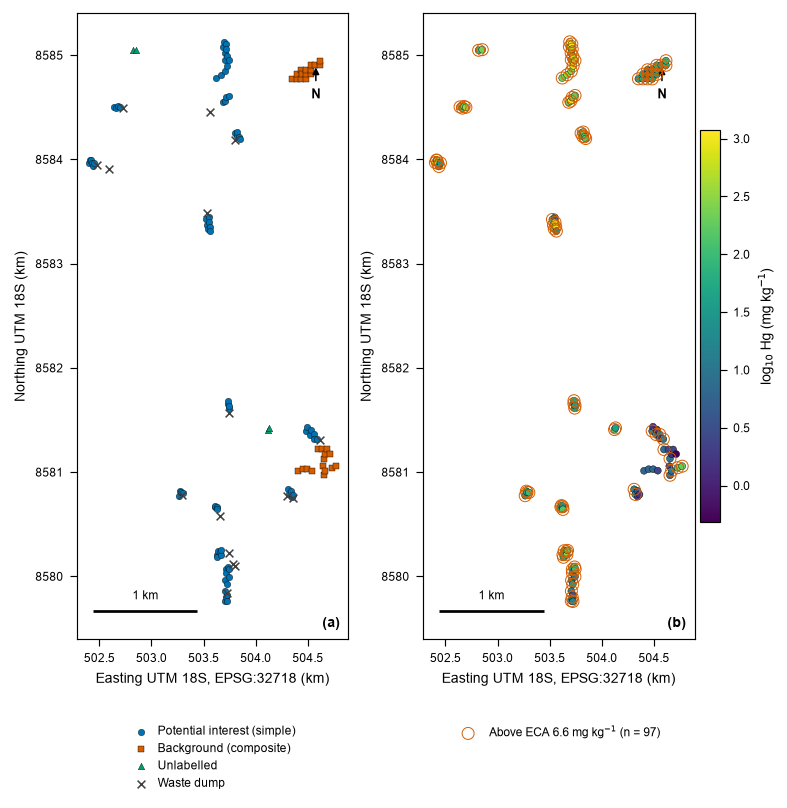

In [17]:
loc1 = final.drop_duplicates("location_id")
hg = final[final.analyte == "Hg"].set_index("location_id")

# The domain is 2.4 km wide by 5.4 km tall, so the panels are deliberately tall and the legends
# sit below the axes rather than inside them, where they would cover the sample clusters.
fig, axes = plt.subplots(1, 2, figsize=(W15, W15 * 1.05), constrained_layout=True)

ax = axes[0]
for st, mk, col, lab in [("potential_interest", "o", OI[0], "Potential interest (simple)"),
                         ("background", "s", OI[1], "Background (composite)"),
                         ("unlabelled", "^", OI[2], "Unlabelled")]:
    s = loc1[loc1.stratum == st]
    ax.scatter(s.easting / 1000, s.northing / 1000, marker=mk, s=11, facecolor=col,
               edgecolor="k", linewidth=0.2, label=lab, zorder=3)
w = workings
ax.scatter(w[w.feature_type == "waste_dump"].easting / 1000,
           w[w.feature_type == "waste_dump"].northing / 1000,
           marker="x", s=16, c="0.25", linewidth=0.8, label="Waste dump", zorder=4)
ax.set_xlabel("Easting UTM 18S, EPSG:32718 (km)")
ax.set_ylabel("Northing UTM 18S (km)")
ax.set_aspect("equal")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), frameon=False, ncol=1,
          handletextpad=0.4, borderaxespad=0)
scale_bar(ax, 1.0, pos=(0.06, 0.03))
north_arrow(ax, pos=(0.88, 0.86), length=0.06)
ax.text(0.97, 0.015, "(a)", transform=ax.transAxes, ha="right", va="bottom", fontweight="bold")

ax = axes[1]
v = hg.loc[loc1.location_id, "value"].to_numpy()
over = v > ECA["Hg"][0]
sc = ax.scatter(loc1.easting / 1000, loc1.northing / 1000, c=np.log10(v), cmap="viridis",
                s=13, edgecolor="k", linewidth=0.2, zorder=3)
ax.scatter(loc1.easting[over] / 1000, loc1.northing[over] / 1000, marker="o", s=38,
           facecolor="none", edgecolor="#D55E00", linewidth=0.5, zorder=4,
           label=f"Above ECA 6.6 mg kg$^{{-1}}$ (n = {int(over.sum())})")
cb = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
cb.set_label(r"log$_{10}$ Hg (mg kg$^{-1}$)")
ax.set_xlabel("Easting UTM 18S, EPSG:32718 (km)")
ax.set_ylabel("Northing UTM 18S (km)")
ax.set_aspect("equal")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), frameon=False, borderaxespad=0)
scale_bar(ax, 1.0, pos=(0.06, 0.03))
north_arrow(ax, pos=(0.88, 0.86), length=0.06)
ax.text(0.97, 0.015, "(b)", transform=ax.transAxes, ha="right", va="bottom", fontweight="bold")

save_fig(fig, "FIG1_sampling_design_and_mercury")
plt.show()

## 13. Export

In [18]:
final.to_csv(DIR_FINAL / "santa_barbara_soil.csv", index=False, encoding="utf-8")
final.to_parquet(DIR_FINAL / "santa_barbara_soil.parquet", index=False)
workings.to_csv(DIR_FINAL / "mine_workings.csv", index=False, encoding="utf-8")
print("exported: santa_barbara_soil.csv / .parquet, mine_workings.csv")

meta_json = {
    "seed": SEED, "crs_utm": CRS_UTM, "crs_geo": CRS_GEO, "report": REPORT_ID,
    "n_locations": int(final["location_id"].nunique()),
    "n_rows": int(len(final)), "n_analytes": int(final["analyte"].nunique()),
    "date_range": [str(final["date"].min()), str(final["date"].max())],
    "domain_extent_km": float(D[np.isfinite(D)].max() / 1000),
    "nn_median_m": float(np.median(nn)), "nn_max_m": float(nn.max()),
    "strata": final.drop_duplicates("location_id")["stratum"].value_counts().to_dict(),
    "analytes": {a: {"role": ROLE[a],
                     "pct_censored": float(100 * g["censored"].mean()),
                     "reported_LOD": None if pd.isna(g["reported_limit"].iloc[0]) else float(g["reported_limit"].iloc[0]),
                     "resolution": float(g["resolution"].iloc[0]),
                     "median_quantified": None if g["value"].isna().all() else float(g["value"].median()),
                     "sd_log": None if g["value"].notna().sum() < 3 else float(np.std(np.log(g["value"].dropna())))}
                 for a, g in final.groupby("analyte")},
    "versions": {m: getattr(__import__(m), "__version__", "n/a")
                 for m in ["numpy", "pandas", "geopandas", "rasterio", "pyproj"]},
}
(DIR_OUT / "nb01_metadata.json").write_text(json.dumps(meta_json, indent=2, ensure_ascii=False),
                                            encoding="utf-8")
print(json.dumps({k: v for k, v in meta_json.items() if k != "analytes"}, indent=2, ensure_ascii=False))

exported: santa_barbara_soil.csv / .parquet, mine_workings.csv
{
  "seed": 20260906,
  "crs_utm": "EPSG:32718",
  "crs_geo": "EPSG:4326",
  "report": "INFORME N° 00341-2018-OEFA/DEAM-STEC",
  "n_locations": 114,
  "n_rows": 1140,
  "n_analytes": 10,
  "date_range": [
    "2018-07-18",
    "2018-09-09"
  ],
  "domain_extent_km": 5.369089494504631,
  "nn_median_m": 33.60724358396727,
  "nn_max_m": 56.302753041036986,
  "strata": {
    "potential_interest": 80,
    "background": 30,
    "unlabelled": 4
  },
  "versions": {
    "numpy": "2.4.6",
    "pandas": "2.3.3",
    "geopandas": "1.1.4",
    "rasterio": "1.5.1",
    "pyproj": "3.7.2"
  }
}


## 14. Data dictionary

In [19]:
DICT = [
    ("location_id", "text", "-", "Stable location identifier derived from the UTM coordinates rounded to the metre.", "derived"),
    ("point_name", "text", "-", "Original OEFA point name. Two names separated by ' | ' mark the single location where two field points share one recorded coordinate.", "OEFA"),
    ("easting", "float", "m", "Easting, UTM zone 18S (EPSG:32718).", "OEFA"),
    ("northing", "float", "m", "Northing, UTM zone 18S (EPSG:32718).", "OEFA"),
    ("lon", "float", "degrees", "Longitude, WGS84 (EPSG:4326).", "derived via pyproj"),
    ("lat", "float", "degrees", "Latitude, WGS84 (EPSG:4326).", "derived via pyproj"),
    ("utm_zone_epsg", "int", "-", "EPSG code of the projected CRS; constant 32718.", "derived"),
    ("elev_oefa", "float", "m a.s.l.", "Elevation recorded in the field by OEFA.", "OEFA"),
    ("elev_dem", "float", "m a.s.l.", "Elevation sampled from the SRTM 30 m DEM at the point.", "SRTM 30 m"),
    ("slope_deg", "float", "degrees", "Terrain slope, Horn (1981) 3x3 gradient on the SRTM DEM.", "SRTM 30 m"),
    ("aspect_deg", "float", "degrees", "Terrain aspect, degrees clockwise from north.", "SRTM 30 m"),
    ("stratum", "text", "-", "Sampling stratum: 'background', 'potential_interest' or 'unlabelled'.", "OEFA"),
    ("sample_type", "text", "-", "Sample support: 'simple' or 'composite'. All background points are composite.", "OEFA"),
    ("sector", "text", "-", "Sector name parsed from the OEFA field description.", "derived from OEFA"),
    ("date", "date", "-", "Sampling date.", "OEFA"),
    ("analyte", "text", "-", "Element symbol: Hg, Pb, As, Ba, Cd, Co, Sb, Ag, Bi, Ni.", "OEFA"),
    ("role", "text", "-", "Role in the study: 'truth field', 'decision metal' or 'censoring gradient'.", "study design"),
    ("value", "float", "mg/kg", "Quantified concentration. Empty when the result is censored: nothing is imputed.", "OEFA"),
    ("censored", "bool", "-", "True when the result was reported as '<L' (left censored).", "derived from OEFA"),
    ("reported_limit", "float", "mg/kg", "Detection limit as published by OEFA. Empty for analytes with no censored result.", "OEFA"),
    ("resolution", "float", "mg/kg", "Laboratory reporting resolution inferred from the decimals of the quantified values. A value reported as 383 means [382.5, 383.5).", "derived"),
    ("unit", "text", "-", "Concentration unit, homogenised to mg/kg dry weight.", "OEFA"),
    ("eca_agricultural", "float", "mg/kg", "Peruvian soil standard, agricultural land use (D.S. 011-2017-MINAM).", "MINAM"),
    ("eca_residential", "float", "mg/kg", "Peruvian soil standard, residential and parks.", "MINAM"),
    ("eca_industrial", "float", "mg/kg", "Peruvian soil standard, commercial, industrial and extractive.", "MINAM"),
    ("dist_waste_dump_m", "float", "m", "Euclidean distance in UTM 18S to the nearest of the 16 waste-rock dumps sampled by OEFA.", "derived from OEFA"),
    ("dist_adit_m", "float", "m", "Distance to the nearest of the 5 outcrop/adit points sampled by OEFA.", "derived from OEFA"),
    ("dist_any_working_m", "float", "m", "Distance to the nearest mine working of any type.", "derived from OEFA"),
    ("dist_city_m", "float", "m", "Distance to the Plaza de Armas of Huancavelica (-74.9758, -12.7867).", "derived"),
    ("coord_flag", "bool", "-", "True for the location where two field points share one recorded coordinate.", "derived, QC"),
    ("description", "text", "-", "Original OEFA field description of the location.", "OEFA"),
]
dic = pd.DataFrame(DICT, columns=["column", "type", "unit", "description", "source"])

lines = [
    "# Data dictionary - `santa_barbara_soil`",
    "",
    "Soil geochemistry dataset for the Santa Bárbara mercury mine, Huancavelica, Peru.",
    "",
    f"- **Layout**: long format, one row per location x analyte.",
    f"- **Rows**: {len(final)} · **Unique locations**: {final['location_id'].nunique()} · "
    f"**Analytes**: {final['analyte'].nunique()}.",
    f"- **Sampling**: {final['date'].min()} to {final['date'].max()}.",
    f"- **Source**: OEFA report {REPORT_ID}, environmental assessment of the Santa Bárbara mining unit.",
    f"- **CRS**: UTM zone 18S (EPSG:32718) and geographic WGS84 (EPSG:4326).",
    f"- **Produced by**: `notebooks/01_dataset_construction.ipynb` (seed {SEED}).",
    "",
    "## Columns",
    "",
    "| Column | Type | Unit | Description | Source |",
    "|---|---|---|---|---|",
]
for _, r in dic.iterrows():
    lines.append(f"| `{r['column']}` | {r['type']} | {r['unit']} | {r['description']} | {r['source']} |")

lines += [
    "",
    "## Notes on use",
    "",
    "1. **Censoring.** `value` is empty on censored rows by design. Do not substitute `L/2`: that",
    "   practice is biased and is precisely the comparison this study makes.",
    "2. **Two supports.** The 30 background points are composite samples and every potential-interest",
    "   point is simple, so stratum and support are almost perfectly aliased. Notebook 2 fits both",
    "   effects and reports their posterior correlation before deciding what can be identified.",
    "3. **Coordinate QC.** One location carries two field point names that share a single recorded",
    "   coordinate (`coord_flag = True`). The coordinate could not be verified, so it was not",
    "   corrected; the two records are averaged in log space and flagged.",
    "4. **Reporting resolution.** Quantified values are recorded to a finite number of decimals, so",
    "   each detection is itself interval-censored. `resolution` gives the interval width.",
    "5. **Regulatory thresholds.** D.S. N.° 011-2017-MINAM, soil environmental quality standards",
    "   (mg/kg dry weight). Cadmium: 1.4 agricultural, 10 residential, 22 industrial.",
    "6. **Not available in the open data.** Sampling depth, laboratory identity and OEFA's own",
    "   conclusions are in the report PDF, which is not published (it is a causality assessment",
    "   feeding a sanctioning procedure). They were not requested for this work.",
    "",
]
(DIR_FINAL / "DATA_DICTIONARY.md").write_text("\n".join(lines), encoding="utf-8")
print("exported: DATA_DICTIONARY.md")
print(dic.to_string(index=False, max_colwidth=55))

exported: DATA_DICTIONARY.md
            column  type     unit                                             description             source
       location_id  text        - Stable location identifier derived from the UTM coor...            derived
        point_name  text        - Original OEFA point name. Two names separated by ' |...               OEFA
           easting float        m                     Easting, UTM zone 18S (EPSG:32718).               OEFA
          northing float        m                    Northing, UTM zone 18S (EPSG:32718).               OEFA
               lon float  degrees                           Longitude, WGS84 (EPSG:4326). derived via pyproj
               lat float  degrees                            Latitude, WGS84 (EPSG:4326). derived via pyproj
     utm_zone_epsg   int        -         EPSG code of the projected CRS; constant 32718.            derived
         elev_oefa float m a.s.l.                Elevation recorded in the field by OEFA.          

## 15. Notebook 1 summary

* **114 unique soil locations** around the Santa Bárbara mercury mine, sampled July–September 2018,
  with ten analytes each (1 140 rows in long format).
* A **stratified design** with 30 background points (composite samples) and 80 points of potential
  interest (simple samples), which is what allows geochemical background to be separated from
  mining input — and which also confounds stratum with support, a limitation carried forward.
* Terrain covariates from a newly downloaded SRTM 30 m DEM, and distances to the **21 mine
  workings whose coordinates OEFA measured directly**.
* The headline finding is already visible: the background stratum itself has a median mercury
  concentration around 31 mg/kg with 70 % of points above the 6.6 mg/kg standard. After four
  centuries of mining there is no clean background.